# Padronização, consolidação e levantamentos — avaliações de foco/concisão

Este notebook fica na mesma pasta dos arquivos `.xlsx` de avaliação. Ao rodar:

1. **Padroniza** os nomes dos arquivos para `{concurso}_batch_{NN}_avaliacao_foco_concisao.xlsx`. É idempotente: rodar de novo não quebra nem renomeia o que já está padrão.
2. **Consolida** todos os arquivos em um único DataFrame.
3. **Valida** o que foi carregado (linhas por arquivo, scores, modelos).
4. Gera **levantamentos** para o TCC.

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

NOTEBOOK_DIR = Path.cwd()
print(f'Pasta de trabalho: {NOTEBOOK_DIR}')
print(f'Arquivos .xlsx na pasta: {len(list(NOTEBOOK_DIR.glob("*.xlsx")))}')

Pasta de trabalho: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/concisao
Arquivos .xlsx na pasta: 15


## 1. Padronização de nomes

Regras:
- O parser reconhece o concurso (`bndes`, `petrobras`, `cvm`) e o número do batch a partir de qualquer variação de nome.
- Alvo: `{concurso}_batch_{NN}_avaliacao_foco_concisao.xlsx` (batch com dois dígitos).
- Se o arquivo já está no formato alvo, é deixado em paz.
- Se renomear causaria sobrescrever um arquivo existente, o conflito é reportado e nada é renomeado.
- Arquivos que o parser não reconhece também são reportados (sem mexer).

In [2]:
CONCURSOS = ('bndes', 'petrobras', 'cvm')
TARGET_SUFFIX = 'avaliacao_foco_concisao'
SEP = r'(?:^|[_\-\.])'

def parse_filename(name: str):
    """Extrai (concurso, batch_num) de qualquer variação. Retorna None se não reconhecer."""
    stem = Path(name).stem.lower()
    concurso = next(
        (c for c in CONCURSOS if re.search(rf'{SEP}{c}(?=[_\-\.]|$)', stem)),
        None,
    )
    if not concurso:
        return None
    m = re.search(r'batch[_\-]?(\d+)', stem)
    if not m:
        return None
    return concurso, int(m.group(1))

def standard_name(concurso: str, batch_num: int) -> str:
    return f'{concurso}_batch_{batch_num:02d}_{TARGET_SUFFIX}.xlsx'

def padronizar_nomes(folder: Path, dry_run: bool = False):
    renames, skipped, conflicts, unparsed = [], [], [], []
    for f in sorted(folder.glob('*.xlsx')):
        parsed = parse_filename(f.name)
        if not parsed:
            unparsed.append(f.name)
            continue
        new_name = standard_name(*parsed)
        if f.name == new_name:
            skipped.append(f.name)
            continue
        target = f.parent / new_name
        if target.exists():
            conflicts.append((f.name, new_name))
            continue
        if not dry_run:
            f.rename(target)
        renames.append((f.name, new_name))
    return renames, skipped, conflicts, unparsed

In [3]:
# Rodar a padronização. Troque dry_run=True para apenas simular.
renames, skipped, conflicts, unparsed = padronizar_nomes(NOTEBOOK_DIR, dry_run=False)

print(f'Renomeados: {len(renames)}')
for old, new in renames:
    print(f'  {old}  ->  {new}')

print(f'\nJa no padrao (mantidos): {len(skipped)}')
for name in skipped:
    print(f'  {name}')

if conflicts:
    print(f'\nCONFLITOS (alvo ja existe, nada foi feito): {len(conflicts)}')
    for old, new in conflicts:
        print(f'  {old}  ->  {new}')

if unparsed:
    print(f'\nNao reconhecidos pelo parser: {len(unparsed)}')
    for name in unparsed:
        print(f'  {name}')

Renomeados: 12
  avaliacao_foco_concisao_bndes_batch_05.xlsx  ->  bndes_batch_05_avaliacao_foco_concisao.xlsx
  avaliacao_foco_concisao_petrobras_batch_02.xlsx  ->  petrobras_batch_02_avaliacao_foco_concisao.xlsx
  avaliacao_foco_concisao_petrobras_batch_03.xlsx  ->  petrobras_batch_03_avaliacao_foco_concisao.xlsx
  bndes_batch_01_avaliacao_long.xlsx  ->  bndes_batch_01_avaliacao_foco_concisao.xlsx
  bndes_batch_02_avaliacao_foco_concisao_long.xlsx  ->  bndes_batch_02_avaliacao_foco_concisao.xlsx
  bndes_batch_03_avaliacao_foco_concisao_long.xlsx  ->  bndes_batch_03_avaliacao_foco_concisao.xlsx
  cvm_batch_01_avaliacoes_long.xlsx  ->  cvm_batch_01_avaliacao_foco_concisao.xlsx
  cvm_batch_02_foco_concisao_long.xlsx  ->  cvm_batch_02_avaliacao_foco_concisao.xlsx
  cvm_batch_03_avaliado_foco_concisao.xlsx  ->  cvm_batch_03_avaliacao_foco_concisao.xlsx
  cvm_batch_04_avaliacao_foco_concisao_long.xlsx  ->  cvm_batch_04_avaliacao_foco_concisao.xlsx
  petrobras_batch_04_avaliacao_foco_concisa

## 2. Consolidação em um DataFrame único

Lê todos os arquivos no padrão, anexa colunas `concurso`, `batch` e `arquivo` de origem.

In [4]:
ESPERADAS = ['id', 'pergunta', 'modelo', 'resposta', 'score', 'justificativa']

def consolidar(folder: Path) -> pd.DataFrame:
    dfs = []
    avisos = []
    for f in sorted(folder.glob(f'*_{TARGET_SUFFIX}.xlsx')):
        parsed = parse_filename(f.name)
        if not parsed:
            continue
        concurso, batch_num = parsed
        df_ = pd.read_excel(f)
        faltando = [c for c in ESPERADAS if c not in df_.columns]
        if faltando:
            avisos.append(f'{f.name}: faltam colunas {faltando}')
        df_['concurso'] = concurso
        df_['batch'] = batch_num
        df_['arquivo'] = f.name
        dfs.append(df_)
    if not dfs:
        return pd.DataFrame(), avisos
    return pd.concat(dfs, ignore_index=True), avisos

df, avisos = consolidar(NOTEBOOK_DIR)
print(f'Total de linhas: {len(df)}')
print(f'Colunas: {list(df.columns)}')
if avisos:
    print('\nAvisos de schema:')
    for a in avisos:
        print(f'  {a}')
df.head()

Total de linhas: 1650
Colunas: ['id', 'pergunta', 'modelo', 'resposta', 'score', 'justificativa', 'concurso', 'batch', 'arquivo']


,id,pergunta,modelo,resposta,score,justificativa,concurso,batch,arquivo
0,1,Qual o período de inscrição para o concurso BNDES?,claude-haiku-4-5,**Período de inscrição do BNDES (01/2024):**\n\nAs inscrições foram realizad...,1,respondeu o período com aviso útil e volume razoável,bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx
1,1,Qual o período de inscrição para o concurso BNDES?,claude-opus-4-7,O período de inscrição para o concurso BNDES (Edital 01/2024) foi:\n\n📅 **De...,0,"despejou isenção, resultado final e oferta sem pedir",bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx
2,1,Qual o período de inscrição para o concurso BNDES?,claude-sonnet-4-6,Aqui estão as informações sobre o período de inscrição do concurso BNDES 01/...,0,"despejou tabela, taxa, prova e resultado sem pedir",bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx
3,1,Qual o período de inscrição para o concurso BNDES?,deepseek-v4-flash,O período de inscrição para o concurso BNDES (Edital 01/2024) foi **das 10h ...,1,respondeu o período com poucos detalhes extras,bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx
4,1,Qual o período de inscrição para o concurso BNDES?,deepseek-v4-pro,O período de inscrição para o concurso do BNDES (Edital 01/2024) foi **das 1...,0,acrescentou isenção e taxa de forma desproporcional,bndes,1,bndes_batch_01_avaliacao_foco_concisao.xlsx


## 3. Validação

Confere se cada arquivo tem o número esperado de linhas (10 perguntas × 11 modelos = 110), se os scores estão no domínio {0, 1}, e quais modelos aparecem.

In [5]:
print('Linhas por arquivo (esperado: 110):')
contagem = (df.groupby(['concurso', 'batch'])
              .size()
              .reset_index(name='n_linhas')
              .sort_values(['concurso', 'batch']))
contagem['ok'] = contagem['n_linhas'] == 110
print(contagem.to_string(index=False))

Linhas por arquivo (esperado: 110):
 concurso  batch  n_linhas   ok
    bndes      1       110 True
    bndes      2       110 True
    bndes      3       110 True
    bndes      4       110 True
    bndes      5       110 True
      cvm      1       110 True
      cvm      2       110 True
      cvm      3       110 True
      cvm      4       110 True
      cvm      5       110 True
petrobras      1       110 True
petrobras      2       110 True
petrobras      3       110 True
petrobras      4       110 True
petrobras      5       110 True


In [6]:
print('Valores de score encontrados:')
print(df['score'].value_counts(dropna=False))

if df['score'].isna().any():
    print(f'\n{df["score"].isna().sum()} linhas com score nulo')

Valores de score encontrados:
score
1    1099
0     551
Name: count, dtype: int64


In [7]:
print(f'Modelos distintos: {df["modelo"].nunique()}')
print('\nContagem por modelo:')
print(df['modelo'].value_counts().to_string())

Modelos distintos: 11

Contagem por modelo:
modelo
claude-haiku-4-5     150
claude-opus-4-7      150
claude-sonnet-4-6    150
deepseek-v4-flash    150
deepseek-v4-pro      150
gpt-4o-mini          150
gpt-5.4              150
gpt-5.4-mini         150
gpt-5.5              150
chatgpt              150
claude_chat          150


In [8]:
# Quais batches estao presentes por concurso
matriz = (df.groupby(['concurso', 'batch']).size()
            .unstack(fill_value=0)
            .astype(int))
print('Linhas por concurso x batch:')
print(matriz)

Linhas por concurso x batch:
batch        1    2    3    4    5
concurso                          
bndes      110  110  110  110  110
cvm        110  110  110  110  110
petrobras  110  110  110  110  110


## 4. Levantamentos para o TCC

A métrica é binária: `score = 1` → resposta focada; `score = 0` → resposta verbosa demais.  
A média do score equivale à **taxa de respostas focadas**.

### 4.1 Visão geral

In [9]:
total = len(df)
focadas = int(df['score'].sum())
verbosas = total - focadas
taxa = df['score'].mean()

print(f'Total de avaliacoes: {total}')
print(f'Respostas focadas (score=1): {focadas} ({focadas/total:.1%})')
print(f'Respostas verbosas (score=0): {verbosas} ({verbosas/total:.1%})')
print(f'Taxa media de foco: {taxa:.3f}')
print(f'\nConcursos cobertos: {sorted(df["concurso"].unique())}')
print(f'Modelos avaliados: {df["modelo"].nunique()}')

Total de avaliacoes: 1650
Respostas focadas (score=1): 1099 (66.6%)
Respostas verbosas (score=0): 551 (33.4%)
Taxa media de foco: 0.666

Concursos cobertos: ['bndes', 'cvm', 'petrobras']
Modelos avaliados: 11


### 4.2 Ranking de modelos por foco/concisão

In [10]:
por_modelo = (df.groupby('modelo')['score']
                .agg(taxa_foco='mean', n_focadas='sum', n_total='count')
                .sort_values('taxa_foco', ascending=False))
por_modelo['n_verbosas'] = por_modelo['n_total'] - por_modelo['n_focadas']
por_modelo[['taxa_foco', 'n_focadas', 'n_verbosas', 'n_total']]

,taxa_foco,n_focadas,n_verbosas,n_total
modelo,,,,
chatgpt,1.000000,150,0,150
gpt-5.4-mini,0.993333,149,1,150
gpt-5.4,0.973333,146,4,150
gpt-5.5,0.973333,146,4,150
gpt-4o-mini,0.886667,133,17,150
deepseek-v4-flash,0.560000,84,66,150
claude-haiku-4-5,0.533333,80,70,150
claude-opus-4-7,0.486667,73,77,150
deepseek-v4-pro,0.473333,71,79,150


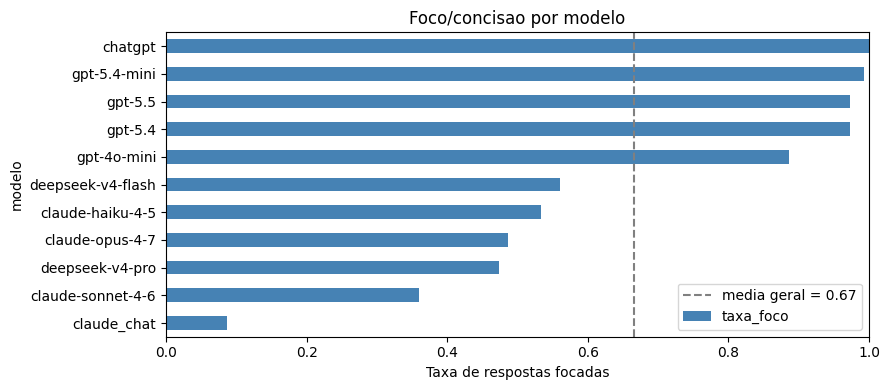

In [11]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(por_modelo))))
por_modelo['taxa_foco'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Taxa de respostas focadas')
ax.set_title('Foco/concisao por modelo')
ax.set_xlim(0, 1)
ax.axvline(df['score'].mean(), linestyle='--', color='gray', label=f'media geral = {df["score"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Foco por concurso

Mostra se algum concurso induz mais verbosidade nos modelos (talvez por ter perguntas mais abertas).

In [12]:
por_concurso = (df.groupby('concurso')['score']
                  .agg(taxa_foco='mean', n_total='count')
                  .sort_values('taxa_foco', ascending=False))
por_concurso

,taxa_foco,n_total
concurso,,
petrobras,0.696364,550
bndes,0.654545,550
cvm,0.647273,550


### 4.4 Modelo x concurso (heatmap)

Olha consistência: um modelo bom em geral também é bom em todos os concursos? Ou varia?

In [13]:
pivot = df.pivot_table(index='modelo', columns='concurso', values='score', aggfunc='mean')
pivot['media'] = pivot.mean(axis=1)
pivot = pivot.sort_values('media', ascending=False)
pivot

concurso,bndes,cvm,petrobras,media
modelo,,,,
chatgpt,1.00,1.00,1.00,1.000000
gpt-5.4-mini,1.00,1.00,0.98,0.993333
gpt-5.4,0.96,0.96,1.00,0.973333
gpt-5.5,0.94,0.98,1.00,0.973333
gpt-4o-mini,0.86,0.88,0.92,0.886667
deepseek-v4-flash,0.54,0.54,0.60,0.560000
claude-haiku-4-5,0.50,0.46,0.64,0.533333
claude-opus-4-7,0.50,0.40,0.56,0.486667
deepseek-v4-pro,0.52,0.42,0.48,0.473333


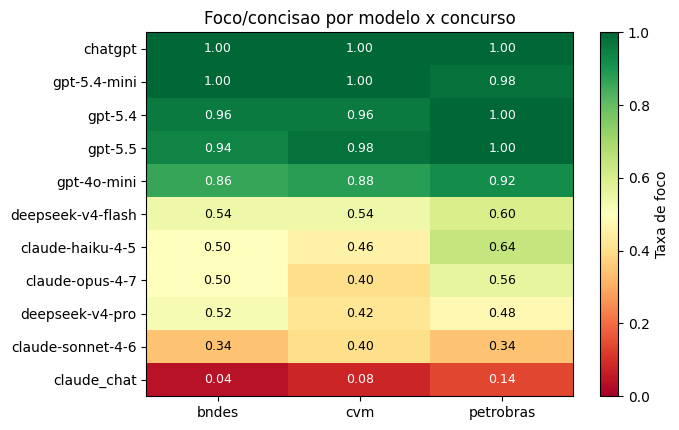

In [14]:
fig, ax = plt.subplots(figsize=(7, max(4, 0.4 * len(pivot))))
data = pivot.drop(columns='media')
im = ax.imshow(data.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(data.columns)))
ax.set_xticklabels(data.columns)
ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='black' if 0.3 < v < 0.7 else 'white', fontsize=9)
plt.colorbar(im, ax=ax, label='Taxa de foco')
ax.set_title('Foco/concisao por modelo x concurso')
plt.tight_layout()
plt.show()

### 4.5 Perguntas que mais induziram verbosidade

Quais perguntas, no agregado dos 11 modelos, tiveram mais respostas verbosas? Útil para discutir no TCC: certas perguntas (mais abertas, mais amplas) ativam o reflexo de "despejar tudo".

In [15]:
por_pergunta = (df.groupby(['concurso', 'batch', 'id', 'pergunta'])['score']
                  .agg(taxa_foco='mean', n_modelos='count')
                  .reset_index()
                  .sort_values('taxa_foco'))
print('Top 10 perguntas com MENOR taxa de foco (mais induziram verbosidade):')
por_pergunta.head(10)

Top 10 perguntas com MENOR taxa de foco (mais induziram verbosidade):


,concurso,batch,id,pergunta,taxa_foco,n_modelos
16,bndes,2,17,Existe possibilidade de impugnar o edital do concurso BNDES?,0.181818,11
40,bndes,5,41,Como é composta a prova discursiva de Ciência de Dados no concurso BNDES?,0.181818,11
17,bndes,2,18,Qual é o cargo/ênfase/perfil de Ciência de Dados no concurso BNDES?,0.272727,11
90,cvm,5,41,Como é composta a prova discursiva de Ciência de Dados no concurso CVM?,0.272727,11
48,bndes,5,49,Como o candidato deve se identificar no dia da prova do concurso BNDES?,0.363636,11
9,bndes,1,10,O candidato precisa guardar o comprovante de inscrição ou pagamento do concu...,0.363636,11
116,petrobras,2,17,Existe possibilidade de impugnar o edital do concurso PETROBRAS?,0.363636,11
14,bndes,2,15,Qual horário de referência deve ser considerado pelo candidato no concurso B...,0.363636,11
105,petrobras,1,6,Quem pode pedir isenção da taxa de inscrição do concurso PETROBRAS?,0.363636,11
94,cvm,5,45,Como é calculada a nota final do concurso CVM para Ciência de Dados?,0.363636,11


In [16]:
print('Top 10 perguntas com MAIOR taxa de foco (todos os modelos foram diretos):')
por_pergunta.tail(10).iloc[::-1]

Top 10 perguntas com MAIOR taxa de foco (todos os modelos foram diretos):


,concurso,batch,id,pergunta,taxa_foco,n_modelos
69,cvm,2,20,Quantas vagas imediatas existem para Ciência de Dados no concurso CVM?,1.000000,11
113,petrobras,2,14,Em quais cidades ou locais as provas do concurso PETROBRAS serão realizadas?,1.000000,11
53,cvm,1,4,Quais são as formas de pagamento da taxa de inscrição do concurso CVM?,1.000000,11
147,petrobras,5,48,Qual tipo de caneta pode ser utilizado para realizar o concurso PETROBRAS?,0.909091,11
149,petrobras,5,50,Quais cuidados o candidato deve ter com o cartão ou folha de respostas no co...,0.909091,11
148,petrobras,5,49,Como o candidato deve se identificar no dia da prova do concurso PETROBRAS?,0.909091,11
128,petrobras,3,29,O cargo de Ciência de Dados exige disponibilidade para viagens no concurso P...,0.909091,11
137,petrobras,4,38,Qual é o critério mínimo de aprovação na prova objetiva do concurso PETROBRAS?,0.909091,11
75,cvm,3,26,Qual escolaridade é exigida para concorrer à área de Ciência de Dados no con...,0.909091,11
83,cvm,4,34,Quantas alternativas existem para as questões objetivas do concurso CVM?,0.909091,11


### 4.6 Análise de justificativas

As justificativas escritas pelo avaliador descrevem *por que* uma resposta foi considerada verbosa. Padrões frequentes aqui viram material qualitativo para o TCC.

In [17]:
print('Justificativas mais frequentes em respostas verbosas (score=0):')
print(df[df['score'] == 0]['justificativa']
        .value_counts()
        .head(20)
        .to_string())

Justificativas mais frequentes em respostas verbosas (score=0):
justificativa
despejou pagamento, devolução e isenção sem pedir             7
despejou como solicitar e regras extras sem pedir             7
detalhou regras e procedimentos além do necessário            6
detalhou contrato e avaliações além do vínculo                6
despejou requisitos adicionais além do recorte pedido         6
despejou salário, jornada e detalhes além das atribuições     6
detalhou procedimentos e documentação além do necessário      5
despejou procedimento e detalhes além do pagamento            5
despejou cronograma e procedimentos sem pedir                 5
despejou pagamento, foto e processo sem pedir                 5
despejou alterações, taxas e regras além do necessário        5
despejou itens do dia da prova e detalhes extras sem pedir    5
despejou critérios de eliminação sem pedir                    4
despejou quem podia pedir e cronograma sem pedir              3
resposta longa demais para

In [18]:
print('Justificativas mais frequentes em respostas focadas (score=1):')
print(df[df['score'] == 1]['justificativa']
        .value_counts()
        .head(10)
        .to_string())

Justificativas mais frequentes em respostas focadas (score=1):
justificativa
respondeu o período com volume razoável                 36
respondeu o prazo com volume razoável                   21
respondeu o site com volume razoável                    19
respondeu a escolaridade com volume razoável            19
respondeu sim com volume razoável                       18
respondeu os locais com volume razoável                 18
respondeu as formas de pagamento com volume razoável    17
respondeu não com volume razoável                       16
respondeu vagas e cadastro com volume razoável          15
respondeu as atribuições com volume razoável            15


### 4.7 Variância entre batches do mesmo modelo

Mede consistência: um modelo é estável ou tem dias bons e ruins?

In [19]:
consistencia = (df.groupby(['modelo', 'concurso', 'batch'])['score']
                  .mean()
                  .reset_index()
                  .groupby('modelo')['score']
                  .agg(media='mean', desvio='std', n_batches='count')
                  .sort_values('desvio'))
print('Modelos por consistencia (menor desvio = mais estavel):')
consistencia

Modelos por consistencia (menor desvio = mais estavel):


,media,desvio,n_batches
modelo,,,
chatgpt,1.000000,0.000000,15
gpt-5.4-mini,0.993333,0.025820,15
gpt-5.4,0.973333,0.045774,15
gpt-5.5,0.973333,0.059362,15
gpt-4o-mini,0.886667,0.124595,15
deepseek-v4-flash,0.560000,0.129835,15
claude_chat,0.086667,0.168466,15
claude-opus-4-7,0.486667,0.172654,15
deepseek-v4-pro,0.473333,0.194447,15


### 4.8 Exportar consolidado

Salva o DataFrame consolidado em `consolidado_foco_concisao.csv` e `.xlsx` para uso fora do notebook.

In [20]:
out_csv = NOTEBOOK_DIR / 'consolidado_foco_concisao.csv'
out_xlsx = NOTEBOOK_DIR / 'consolidado_foco_concisao.xlsx'
df.to_csv(out_csv, index=False)
df.to_excel(out_xlsx, index=False)
print(f'Salvo: {out_csv.name}')
print(f'Salvo: {out_xlsx.name}')

Salvo: consolidado_foco_concisao.csv
Salvo: consolidado_foco_concisao.xlsx
